In [27]:
#câu 1:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nạp dữ liệu
df = sns.load_dataset('titanic')

# 1. In ra 5 dòng đầu
print(df.head())

# 2. In thông tin tổng quan
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [16]:
#câu 2:
# 1. Đếm số lượng giá trị khuyết
print(df.isnull().sum())

# 2. Xóa cột 'deck'
if 'deck' in df.columns:
    df = df.drop(columns=['deck'])
else:
    print("Column 'deck' not found, it might have been dropped already.")

# 3. Điền giá trị khuyết cột 'age' bằng trung bình
df['age'] = df['age'].fillna(df['age'].mean())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64
Column 'deck' not found, it might have been dropped already.


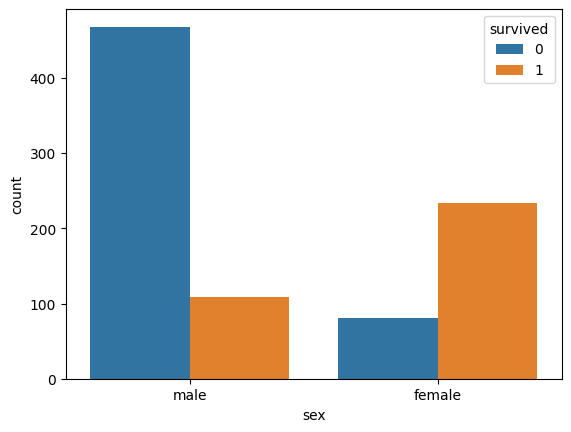

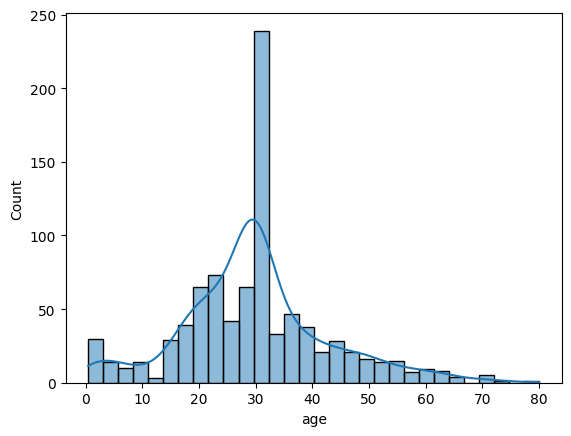

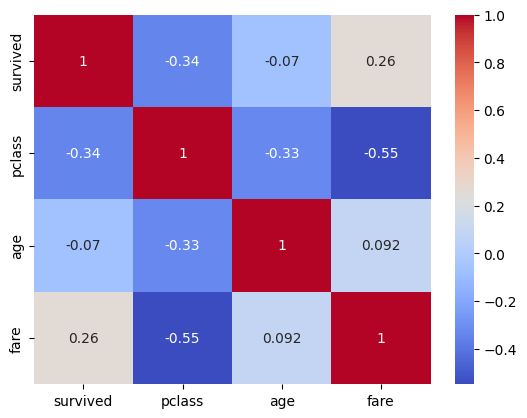

In [18]:
import matplotlib.pyplot as plt

# 1. Biểu đồ cột hành khách sống sót phân chia theo giới tính
sns.countplot(data=df, x='sex', hue='survived')
plt.show()

# 2. Biểu đồ phân bố độ tuổi
sns.histplot(df['age'], kde=True)
plt.show()

# 3. Ma trận tương quan và Heatmap
corr_matrix = df[['survived', 'pclass', 'age', 'fare']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [28]:
# 1. Label Encoding cho cột 'sex'
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

# 2. One-Hot Encoding cho cột 'embarked'
if 'embarked' in df.columns:
    df = pd.get_dummies(df, columns=['embarked'])
else:
    print("Column 'embarked' not found, it might have been one-hot encoded already.")

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Tạo biến X và y
X = df[['pclass', 'sex', 'age']]
y = df['survived']

# 2. Chia dữ liệu train/test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)